# Практична робота №3.
# Класифiкацiя та регресія на основі багатошарового персептрона
Варіант 25 \
Виконали студенти групи КА-35 Бернацький Артем, Бубало Анна, Іванкевич Богдан, Шальман Тимофій

# Dataset A

In [60]:
from sklearn.datasets import make_blobs
import numpy as np


X, y_true = make_blobs (
    n_samples=400,
    centers=4,
    cluster_std=0.60,
    random_state=0
)

rng = np.random.RandomState(13)
X_stretched = np.dot(X, rng.randn(2, 2))

### Візуалізація датасету

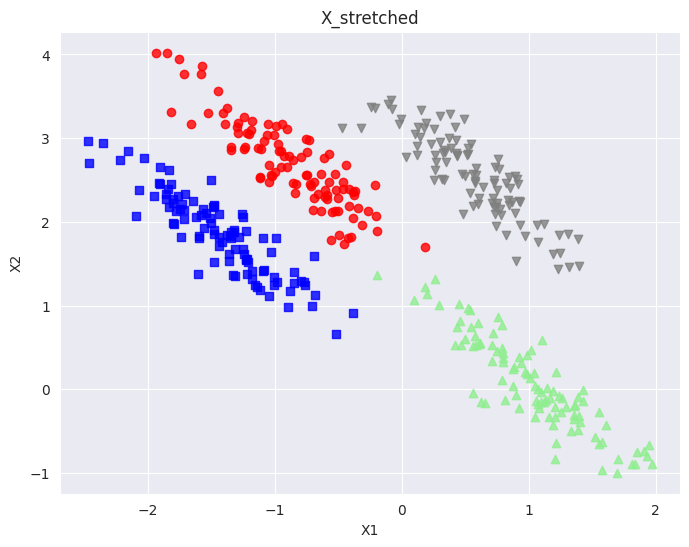

In [61]:
import matplotlib.pyplot as plt


def show_scatter(X, y, title=None):
    markers = ('o', 's', '^', 'v', '<')
    colors = ('red', 'blue', 'lightgreen', 'gray', 'cyan')
    plt.figure(figsize=(8, 6))
    for idx, cl in enumerate(np.unique(y)):
        plt.scatter(
            X[y == cl, 0],
            X[y == cl, 1],
            alpha=0.8,
            c=colors[idx],
            marker=markers[idx],
            label=f'Class {cl}'
        )
    plt.title(title)
    if title:
        plt.title(title)
    plt.xlabel("X1")
    plt.ylabel("X2")
    plt.show()

show_scatter(X_stretched, y_true, title="X_stretched")

## Реалізація функцій для виводу метрик та візуалізації роботи моделі

In [62]:
from matplotlib.colors import ListedColormap


def plot_decision_regions(X, y, classifier, classifier_name, resolution=0.02):
    """
    Візуалізація меж класифікації.
    Параметри:
        X                - ознаки
        y                - справжні мітки
        classifier       - навчена модель
        classifier_name  - назва моделі,
                     яка відображається в заголовку графіка
        resolution - крок сітки для побудови областей
    """

    markers = ('o','s','^','v','<')
    colors = ('red','blue','lightgreen','gray','cyan')
    cmap = ListedColormap(colors[:len(np.unique(y))])

    # Створюємо сітку точок для візуалізації меж
    x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    # Створюємо сітку координат
    xx1, xx2 = np.meshgrid(
        np.arange(x1_min, x1_max, resolution),
        np.arange(x2_min, x2_max, resolution)
    )

    # Прогноз для кожної точки сітки
    lab = classifier.predict(np.array([xx1.ravel(), xx2.ravel()]).T)
    lab = lab.reshape(xx1.shape)

    # Малюємо графік
    plt.figure(figsize=(8, 6))
    plt.contourf(xx1, xx2, lab, alpha=0.3, cmap=cmap)
    plt.xlim(xx1.min(), xx1.max())
    plt.ylim(xx2.min(), xx2.max())
    plt.title(classifier_name)
    plt.xlabel("X1")
    plt.ylabel("X2")
    for idx, cl in enumerate(np.unique(y)):
        plt.scatter(
            x=X[y == cl,0],
            y=X[y == cl,1],
            alpha=0.8,
            c=colors[idx],
            marker=markers[idx],
            label=f"Class {cl}",
            edgecolor="black"
        )

    plt.show()

In [63]:
import seaborn as sns
import sklearn.metrics as metrics
from sklearn.metrics import accuracy_score


def get_classifier_score(X, y, classifier):
    """
    Розрахунок та виведення значень критеріїв якості.
    Параметри:
        X                - ознаки
        y                - справжні мітки
        classifier       - навчена модель
    """

    y_pred = classifier.predict(X)

    class_names = [f"Class {i}" for i in np.unique(y).astype(int)]

    # Вивід значення критеріїв якості
    print(metrics.classification_report(y, y_pred, target_names=class_names))

    # Матриця неточностей
    conf_matrix = metrics.confusion_matrix(y, y_pred)
    plt.figure(figsize =(6, 6))
    sns.heatmap(
        data=conf_matrix,
        xticklabels=class_names,
        yticklabels=class_names,
        annot=True,
        fmt="d",
        square=True,
        cmap="coolwarm",
        vmax=20
    )
    plt.ylabel("True class")
    plt.xlabel("Predicted class")
    plt.show()

In [64]:
from sklearn.preprocessing import label_binarize


def plot_roc_auc(X, y, classifier):
    """
    Побудова ROC–AUC кривої для бінарної або мультикласової класифікації.
    Параметри:
        X                - ознаки
        y                - справжні мітки
        classifier       - навчена модель
    """

    # Отримуємо ймовірності та кількість класів
    y_score = classifier.predict_proba(X)
    classes = np.unique(y)
    n_classes = len(classes)

    # Якщо бінарна класифікація
    if n_classes == 2:
        if y_score.ndim > 1:
            y_score = y_score[:, 1]
        fpr, tpr, _ = metrics.roc_curve(y, y_score)
        roc_auc = metrics.auc(fpr, tpr)

        plt.figure()
        plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
        plt.plot([0, 1], [0, 1], "k:", alpha=0.5)
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title("ROC-curve")
        plt.legend()
        plt.show()
        print(f"ROC–AUC = {roc_auc:.3f}")

    # Якщо мультикласова класифікація
    else:
        y_bin = label_binarize(y, classes=classes)
        if y_score.ndim == 1 or y_score.shape[1] == 1:
            y_score = label_binarize(y_score, classes=classes)

        fpr, tpr, roc_auc = {}, {}, {}
        for i in range(n_classes):
            if np.sum(y_bin[:, i]) == 0:
                continue  # пропускаємо класи без позитивних прикладів
            fpr[i], tpr[i], _ = metrics.roc_curve(y_bin[:, i], y_score[:, i])
            roc_auc[i] = metrics.auc(fpr[i], tpr[i])

        # Усереднений (macro) ROC–AUC
        all_fpr = np.unique(np.concatenate([fpr[i] for i in fpr]))
        mean_tpr = np.zeros_like(all_fpr)
        for i in fpr:
            mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
        mean_tpr /= len(fpr)
        macro_auc = metrics.auc(all_fpr, mean_tpr)

        plt.figure()
        for i in fpr:
            plt.plot(fpr[i], tpr[i], label=f"Class {classes[i]} (AUC = {roc_auc[i]:.3f})")
        plt.plot([0, 1], [0, 1], "k:", alpha=0.5)
        plt.xlabel("False Positive Rate")
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title("ROC-curve")
        plt.legend()
        plt.show()

        print(f"Macro-average ROC-AUC = {macro_auc:.3f}")

In [65]:
def plot_pr_curve(X, y, classifier):
    """
    Побудова Precision-Recall кривої для бінарної або мультикласової класифікації.
    Параметри:
        X                - ознаки
        y                - справжні мітки
        classifier       - навчена модель
    """

    # Отримуємо ймовірності та кількість класів
    y_score = classifier.predict_proba(X)
    classes = np.unique(y)
    n_classes = len(classes)

    # Бінарна класифікація
    if n_classes == 2:
        if y_score.ndim > 1:
            y_score = y_score[:, 1]
        precision, recall, _ = metrics.precision_recall_curve(y, y_score)
        ap = metrics.average_precision_score(y, y_score)

        plt.figure()
        plt.plot(recall, precision, label=f"AP = {ap:.3f}")
        plt.plot([1, 0], [0, 1], "k:", alpha=0.5)
        plt.xlabel("Recall")
        plt.ylabel("Precision")
        plt.title("Precision–Recall Curve")
        plt.grid(True, linestyle='--', alpha=0.6)
        plt.legend()
        plt.show()
        print(f"Average (AUC PR) = {ap:.3f}")

    # Мультикласова класифікація
    else:
        y_bin = label_binarize(y, classes=classes)
        if y_score.ndim == 1 or y_score.shape[1] == 1:
            y_score = label_binarize(y_score, classes=classes)

        precision, recall, ap = {}, {}, {}
        for i in range(n_classes):
            if np.sum(y_bin[:, i]) == 0:
                continue  # пропускаємо класи без позитивних прикладів
            precision[i], recall[i], _ = metrics.precision_recall_curve(y_bin[:, i], y_score[:, i])
            ap[i] = metrics.average_precision_score(y_bin[:, i], y_score[:, i])

        # Усереднення
        all_recall = np.unique(np.concatenate([recall[i] for i in recall]))
        mean_precision = np.zeros_like(all_recall)
        for i in recall:
            mean_precision += np.interp(all_recall, recall[i][::-1], precision[i][::-1])
        mean_precision /= len(recall)
        macro_ap = np.mean(list(ap.values()))

        plt.figure()
        for i in precision:
            plt.plot(recall[i], precision[i], label=f"Class {classes[i]} (AP = {ap[i]:.3f})")
        plt.plot([1, 0], [0, 1], "k:", alpha=0.5)
        plt.xlabel("Recall")
        plt.ylabel("Precision")
        plt.title("Precision–Recall Curve")
        plt.grid(True, linestyle='--', alpha=0.6)
        plt.legend()
        plt.show()

        print(f"Macro-average (AUC PR) = {macro_ap:.3f}")

### Розділ вибірки на навчальну та тестову

In [66]:
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(
    X_stretched, y_true, test_size=0.25, random_state=0
)

## Ініціалізація та навчання моделі MLPClassifier

In [67]:
from sklearn.neural_network import MLPClassifier
import warnings


warnings.filterwarnings('ignore', module='sklearn')

# Дефолтні значення
# (тільки max_iter=500, бо з adam оптимізатором
# погано сходиться на стандартних значеннях)
clf = MLPClassifier(
    hidden_layer_sizes=(100,),
    activation='relu',
    solver='adam',
    alpha=0.0001,
    max_iter=500,
    random_state=42
)

### Оцінка продуктивності моделі та візуалізація зі стандартними параметрами

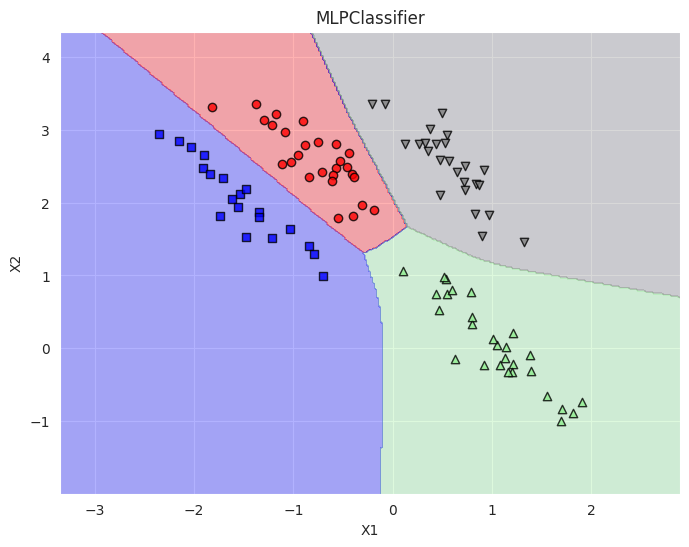

In [68]:
clf.fit(X_train, y_train)
plot_decision_regions(X_test, y_test, clf, classifier_name="MLPClassifier")

Evaluation metrics for train set:
              precision    recall  f1-score   support

     Class 0       0.99      0.99      0.99        73
     Class 1       1.00      1.00      1.00        80
     Class 2       1.00      1.00      1.00        72
     Class 3       0.99      0.99      0.99        75

    accuracy                           0.99       300
   macro avg       0.99      0.99      0.99       300
weighted avg       0.99      0.99      0.99       300



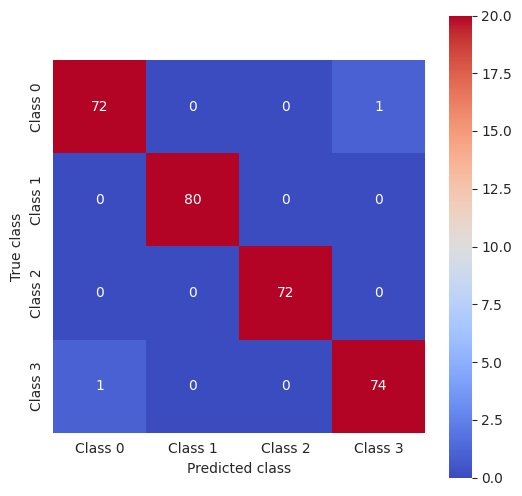

Evaluation metrics for test set:
              precision    recall  f1-score   support

     Class 0       1.00      1.00      1.00        27
     Class 1       1.00      1.00      1.00        20
     Class 2       1.00      1.00      1.00        28
     Class 3       1.00      1.00      1.00        25

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100



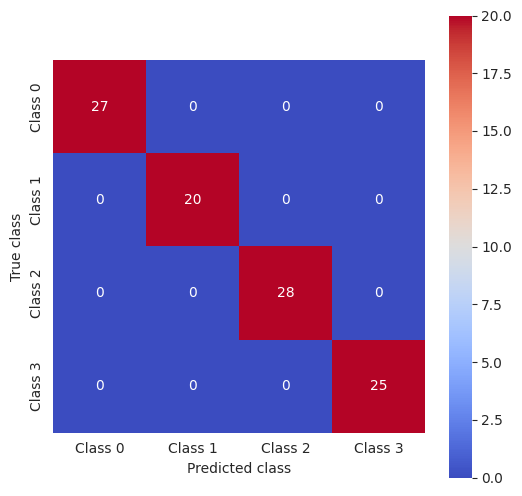

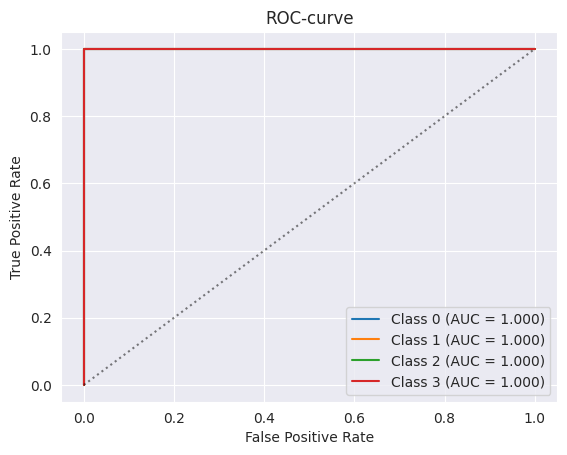

Macro-average ROC-AUC = 1.000


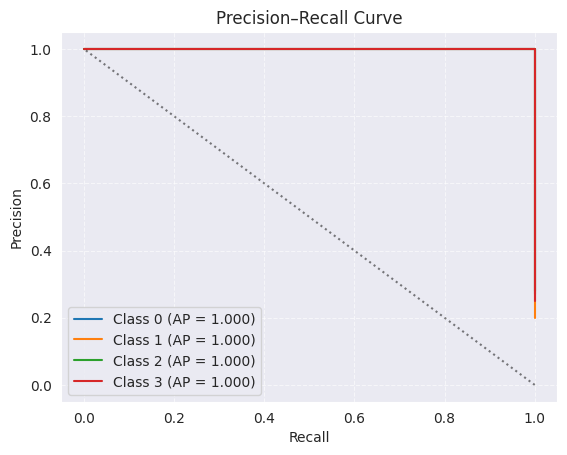

Macro-average (AUC PR) = 1.000


In [69]:
print("Evaluation metrics for train set:")
get_classifier_score(X_train, y_train, clf)

print("Evaluation metrics for test set:")
get_classifier_score(X_test, y_test, clf)
plot_roc_auc(X_test, y_test,clf)
plot_pr_curve(X_test, y_test,clf)

In [70]:
# Overfitting
train_acc = accuracy_score(y_train, clf.predict(X_train))
test_acc = accuracy_score(y_test, clf.predict(X_test))
print(f"{(train_acc - test_acc):.4f}")

-0.0067


MLP з стандартними параметрами (один скритий шар з 100 нейронами) вже достатньо для правильної класифікації нашого датасету.

### Перевірка роботи моделі на тренувальних вибірках різного розміру

In [71]:
train_sizes = [0.1, 0.3, 0.5, 0.7, 0.9]
for size in train_sizes:
    X_sub, _, y_sub, _ = train_test_split(X_train, y_train, test_size=1-size, random_state=0)
    clf.fit(X_sub, y_sub)
    acc = accuracy_score(y_test, clf.predict(X_test))
    print(f"Train size = {len(X_sub)} Accuracy = {acc}")

Train size = 30 Accuracy = 1.0
Train size = 90 Accuracy = 1.0
Train size = 150 Accuracy = 1.0
Train size = 209 Accuracy = 1.0
Train size = 270 Accuracy = 1.0


Навіть при невеликому наборі даних нейронна мережа здатна навчитися розділяти класи, а подальше збільшення лише підтверджує правильність класифікації.

## Динамічне додавання нейронів до скритого шару

In [72]:
threshold = 0.95
neurons_num = [1, 5, 10, 50, 100]
tries = 3
min_neurons_num = neurons_num[-1]

for i in range(tries):
  print(f"Iteration: {i}")

  for n in neurons_num:
    clf_dynamic = MLPClassifier(hidden_layer_sizes=(n,),
                        warm_start=True,
                        max_iter=200)

    clf_dynamic.fit(X_train, y_train)
    model_score = clf_dynamic.score(X_test, y_test)

    print(f"\tScore with {n} neurons: {model_score:.4f}")

    if model_score >= threshold:
      curr_neurons = n
      break

    curr_neurons = n

  if curr_neurons < min_neurons_num:
    min_neurons_num = curr_neurons

print(f"\nMinimal number of neurons ~ {min_neurons_num}")

Iteration: 0
	Score with 1 neurons: 0.4800
	Score with 5 neurons: 0.8600
	Score with 10 neurons: 0.9700
Iteration: 1
	Score with 1 neurons: 0.2900
	Score with 5 neurons: 0.8300
	Score with 10 neurons: 0.9900
Iteration: 2
	Score with 1 neurons: 0.2700
	Score with 5 neurons: 0.4500
	Score with 10 neurons: 0.9700

Minimal number of neurons ~ 10


Як бачимо, за три спроби одношарова (10, 1) модель задовільно справилась з задачею, датасетом А.

## Знаходження оптимального варіанту архітектури

In [73]:
from sklearn.model_selection import GridSearchCV
import warnings


warnings.filterwarnings('ignore', module='sklearn')

param_grid_mlp = {
    "hidden_layer_sizes": [(10,), (50,), (100,),
                           (10, 5), (64, 32), (100, 50), (128, 64)],
    "activation": ["relu", "tanh", "sigmoid"],
    "solver": ["adam", "lbfgs", "sgd"],
}

grid_mlp = GridSearchCV(clf, param_grid_mlp, cv=5, verbose=1)
grid_mlp.fit(X_train, y_train)

print(f"Best params:    {grid_mlp.best_params_}")
print(f"Train accuracy: {grid_mlp.best_score_}")
print(f"Test accuracy:  {accuracy_score(y_test, grid_mlp.best_estimator_.predict(X_test))}")

Fitting 5 folds for each of 63 candidates, totalling 315 fits
Best params:    {'activation': 'tanh', 'hidden_layer_sizes': (100,), 'solver': 'lbfgs'}
Train accuracy: 1.0
Test accuracy:  1.0


`GridSearchCV` показав, що найоптимальніший варіант архітектури MLP для розв'язання задачі з датасетом А - це `hidden_layer_sizes = (128, 64)`, `solver = adam`, `activation = tanh`.

### Оцінка продуктивності моделі та візуалізація з підібраним варіантом архітектури

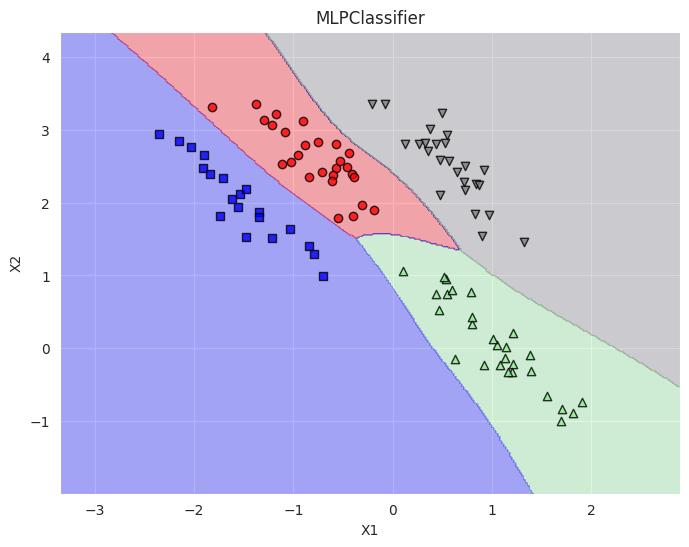

In [74]:
plot_decision_regions(X_test, y_test, grid_mlp, classifier_name="MLPClassifier")

Evaluation metrics for train set:
              precision    recall  f1-score   support

     Class 0       0.97      0.99      0.98        73
     Class 1       1.00      1.00      1.00        80
     Class 2       1.00      0.99      0.99        72
     Class 3       0.99      0.99      0.99        75

    accuracy                           0.99       300
   macro avg       0.99      0.99      0.99       300
weighted avg       0.99      0.99      0.99       300



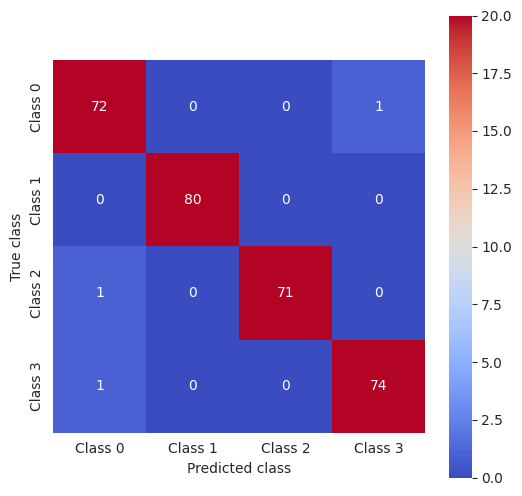

Evaluation metrics for test set:
              precision    recall  f1-score   support

     Class 0       1.00      1.00      1.00        27
     Class 1       1.00      1.00      1.00        20
     Class 2       1.00      1.00      1.00        28
     Class 3       1.00      1.00      1.00        25

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100



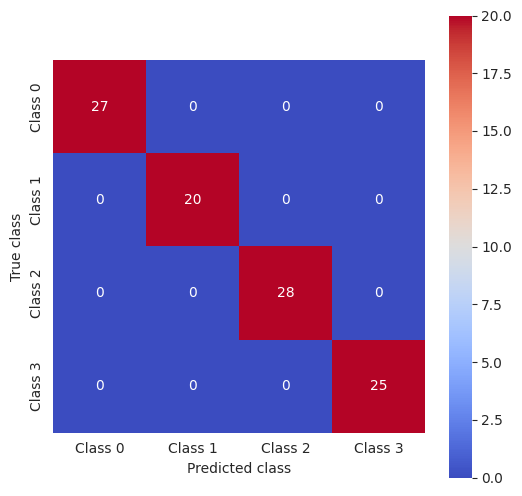

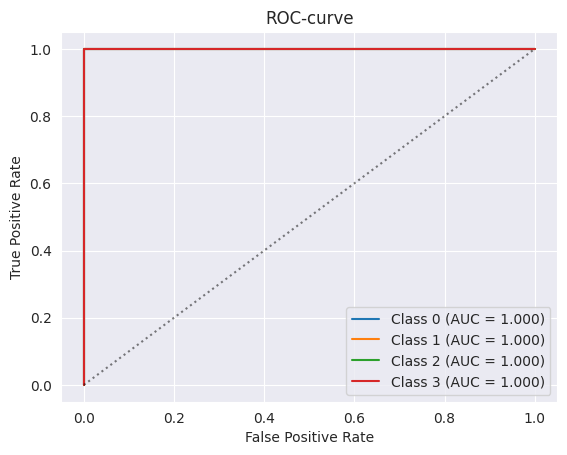

Macro-average ROC-AUC = 1.000


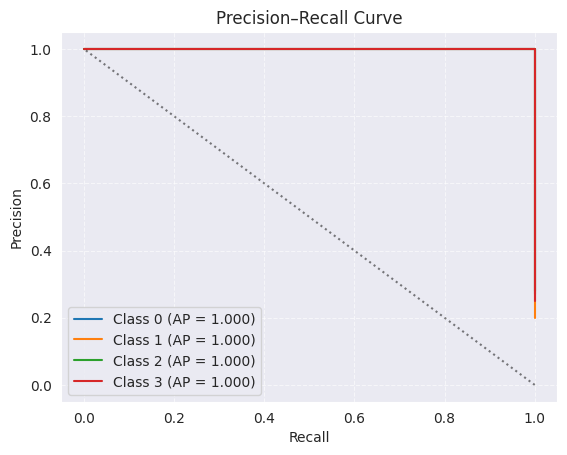

Macro-average (AUC PR) = 1.000


In [75]:
print("Evaluation metrics for train set:")
get_classifier_score(X_train, y_train, clf)

print("Evaluation metrics for test set:")
get_classifier_score(X_test, y_test, clf)
plot_roc_auc(X_test, y_test,clf)
plot_pr_curve(X_test, y_test,clf)

In [76]:
# Overfitting
train_acc = accuracy_score(y_train, grid_mlp.predict(X_train))
test_acc = accuracy_score(y_test, grid_mlp.predict(X_test))
print(f"{(train_acc - test_acc):.4f}")

0.0000


Після налаштування архітектури мережі модель показала **ідеальні результати** та відсутність помилок у матриці неточностей.

# Dataset B

In [77]:
np.random.seed(0)
X = np.random.randn(300, 2)
y = np.logical_xor(X[:, 0] > 0, X[:, 1] > 0)

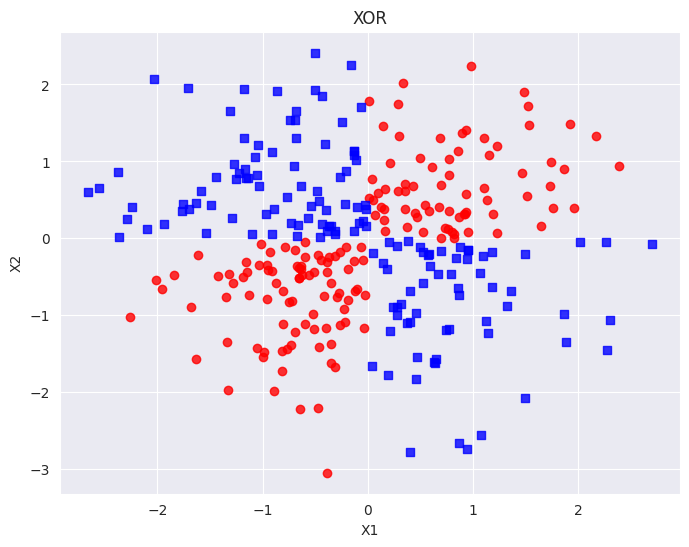

In [78]:
show_scatter(X, y, title="XOR")

## Розділ вибірки на навчальну і тестову та навчання моделі

In [79]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=0, stratify=y
)

# Дефолтні значення
# (тільки max_iter=500, бо з adam оптимізатором
# погано сходиться на дефолних значеннях)
clf = MLPClassifier(
    hidden_layer_sizes=(100,),
    activation='relu',
    solver='adam',
    alpha=0.0001,
    max_iter=500,
    random_state=42
)

### Оцінка продуктивності моделі та візуалізація зі стандартними параметрами

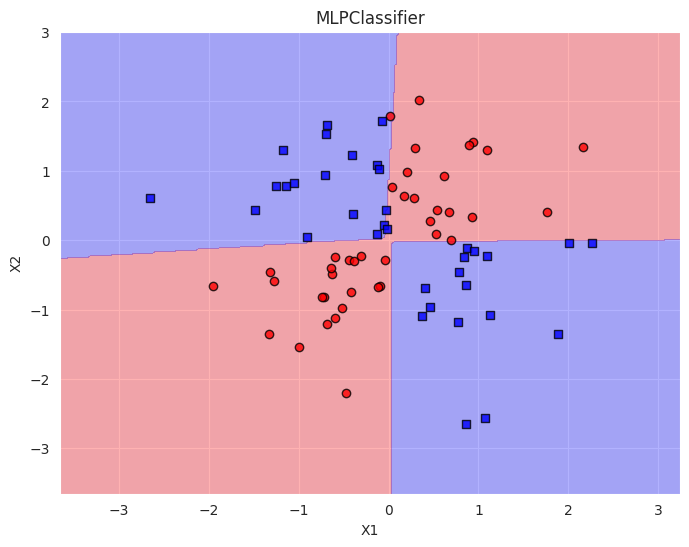

In [80]:
clf.fit(X_train, y_train)
plot_decision_regions(X_test, y_test, clf, classifier_name="MLPClassifier")

Evaluation metrics for train set:
              precision    recall  f1-score   support

     Class 0       0.99      1.00      1.00       118
     Class 1       1.00      0.99      1.00       107

    accuracy                           1.00       225
   macro avg       1.00      1.00      1.00       225
weighted avg       1.00      1.00      1.00       225



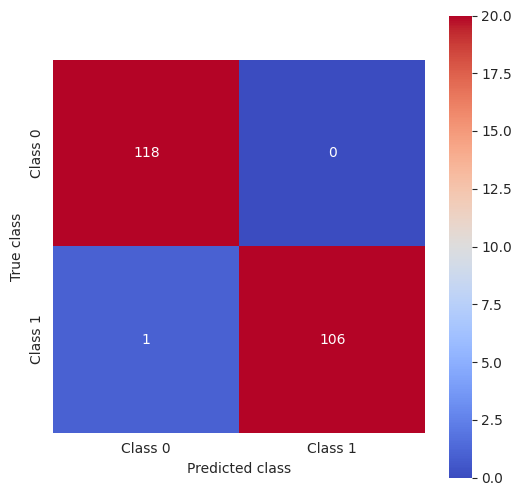

Evaluation metrics for test set:
              precision    recall  f1-score   support

     Class 0       0.97      0.97      0.97        40
     Class 1       0.97      0.97      0.97        35

    accuracy                           0.97        75
   macro avg       0.97      0.97      0.97        75
weighted avg       0.97      0.97      0.97        75



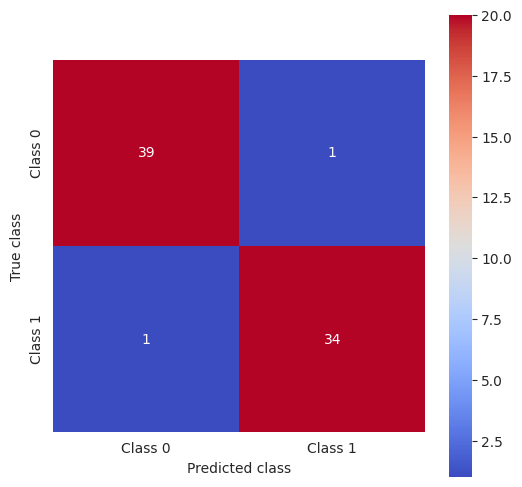

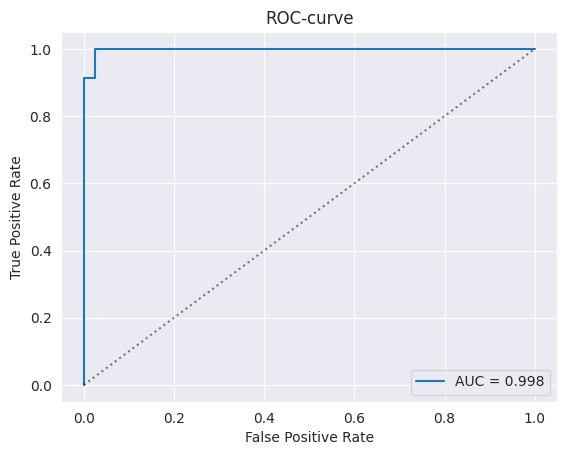

ROC–AUC = 0.998


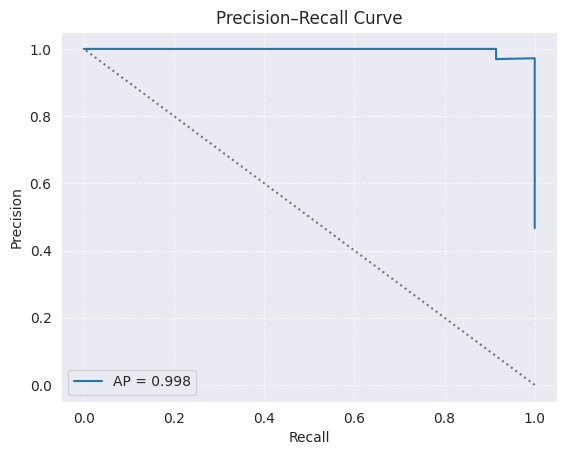

Average (AUC PR) = 0.998


In [81]:
print("Evaluation metrics for train set:")
get_classifier_score(X_train, y_train, clf)

print("Evaluation metrics for test set:")
get_classifier_score(X_test, y_test, clf)
plot_roc_auc(X_test, y_test,clf)
plot_pr_curve(X_test, y_test,clf)

In [82]:
# Overfitting
train_acc = accuracy_score(y_train, clf.predict(X_train))
test_acc = accuracy_score(y_test, clf.predict(X_test))
print(f"{(train_acc - test_acc):.4f}")

0.0222


З використанням стандартних параметрів модель продемонструвала високу якість класифікації досягнувши точності **97%** на тестовому наборі даних

### Перевірка роботи моделі на тренувальних вибірках різного розміру

In [83]:
train_sizes = [0.1, 0.3, 0.5, 0.7, 0.9]
for size in train_sizes:
    X_sub, _, y_sub, _ = train_test_split(X_train, y_train, test_size=1-size, random_state=0)
    clf.fit(X_sub, y_sub)
    acc = accuracy_score(y_test, clf.predict(X_test))
    print(f"Train size = {len(X_sub)} Accuracy = {acc}")

Train size = 22 Accuracy = 0.92
Train size = 67 Accuracy = 0.9066666666666666
Train size = 112 Accuracy = 0.9333333333333333
Train size = 157 Accuracy = 0.92
Train size = 202 Accuracy = 0.96


Навіть при малому числі тренувальних прикладів точність моделі на тестовій вибірці становить **92%**. При збільшенні кількості даних точність коливається в діапазоні **90%-96%**, не демонструючи суттєвого падіння чи нестабільності.

## Динамічне додавання нейронів до скритого шару

In [84]:
threshold = 0.95
neurons_num = [1, 5, 10, 50, 100]
tries = 3
min_neurons_num = neurons_num[-1]

for i in range(tries):
  print(f"Iteration: {i + 1}")

  for n in neurons_num:
    clf_dynamic = MLPClassifier(hidden_layer_sizes=(n,),
                        warm_start=True,
                        max_iter=200)

    clf_dynamic.fit(X_train, y_train)
    model_score = clf_dynamic.score(X_test, y_test)

    print(f"\tScore with {n} neurons: {model_score:.4f}")

    if model_score >= threshold:
      curr_neurons = n
      break

    curr_neurons = n

  if curr_neurons < min_neurons_num:
    min_neurons_num = curr_neurons

print(f"\nMinimal number of neurons ~ {min_neurons_num}")

Iteration: 1
	Score with 1 neurons: 0.5467
	Score with 5 neurons: 0.7867
	Score with 10 neurons: 0.7733
	Score with 50 neurons: 0.9333
	Score with 100 neurons: 0.9733
Iteration: 2
	Score with 1 neurons: 0.5333
	Score with 5 neurons: 0.7067
	Score with 10 neurons: 0.7333
	Score with 50 neurons: 0.9333
	Score with 100 neurons: 0.9467
Iteration: 3
	Score with 1 neurons: 0.6400
	Score with 5 neurons: 0.6933
	Score with 10 neurons: 0.6933
	Score with 50 neurons: 0.9200
	Score with 100 neurons: 0.9733

Minimal number of neurons ~ 100


Як бачимо, за три спроби одношарова (100, 1) модель задовільно справилась з задачею, датасетом B.

## Знаходження оптимального варіанту архітектури

In [85]:
from sklearn.model_selection import GridSearchCV
import warnings


warnings.filterwarnings('ignore', module='sklearn')

param_grid_mlp = {
    "hidden_layer_sizes": [(10,), (50,), (100,),
                           (16, 8), (64, 32), (100, 50), (128, 64)],
    "activation": ["relu", "tanh", "sigmoid"],
    "solver": ["adam", "lbfgs", "sgd"],
}

grid_mlp = GridSearchCV(clf, param_grid_mlp, cv=5, verbose=1)
grid_mlp.fit(X_train, y_train)

print(f"Best params:    {grid_mlp.best_params_}")
print(f"Train accuracy: {grid_mlp.best_score_}")
print(f"Test accuracy:  {accuracy_score(y_test, grid_mlp.best_estimator_.predict(X_test))}")

Fitting 5 folds for each of 63 candidates, totalling 315 fits
Best params:    {'activation': 'relu', 'hidden_layer_sizes': (50,), 'solver': 'lbfgs'}
Train accuracy: 0.9911111111111112
Test accuracy:  0.9866666666666667


`GridSearchCV` показав, що найоптимальніший варіант архітектури MLP для розв'язання задачі з датасетом А - це `hidden_layer_sizes = (50, 1)`, `solver = lbfgs`, `activation = relu`.

### Оцінка продуктивності моделі та візуалізація з підібраним варіантом архітектури

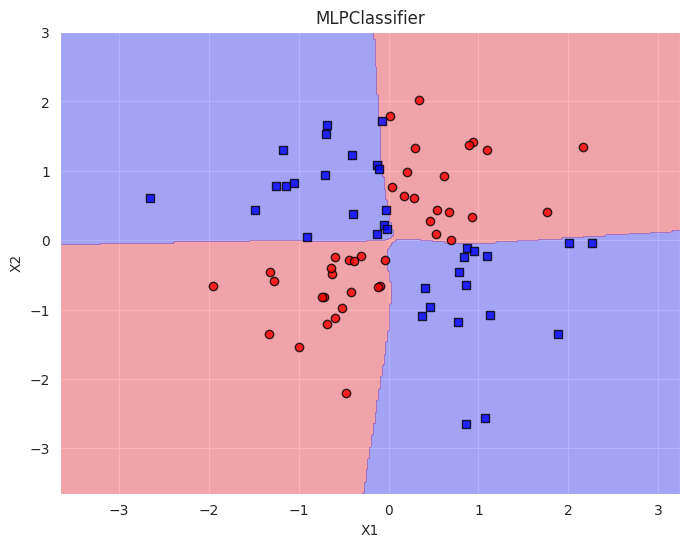

In [86]:
plot_decision_regions(X_test, y_test, grid_mlp, classifier_name="MLPClassifier")

Evaluation metrics for train set:
              precision    recall  f1-score   support

     Class 0       1.00      1.00      1.00       118
     Class 1       1.00      1.00      1.00       107

    accuracy                           1.00       225
   macro avg       1.00      1.00      1.00       225
weighted avg       1.00      1.00      1.00       225



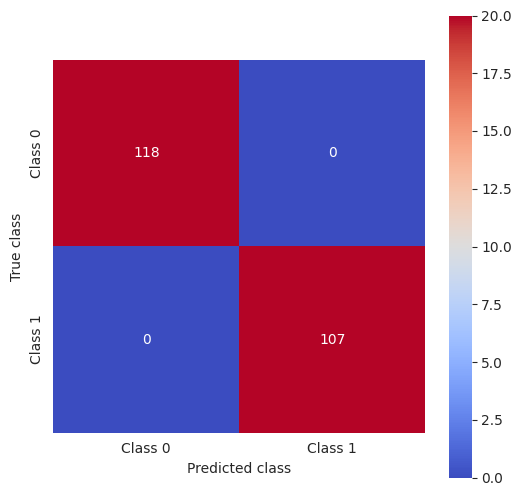

Evaluation metrics for test set:
              precision    recall  f1-score   support

     Class 0       0.98      1.00      0.99        40
     Class 1       1.00      0.97      0.99        35

    accuracy                           0.99        75
   macro avg       0.99      0.99      0.99        75
weighted avg       0.99      0.99      0.99        75



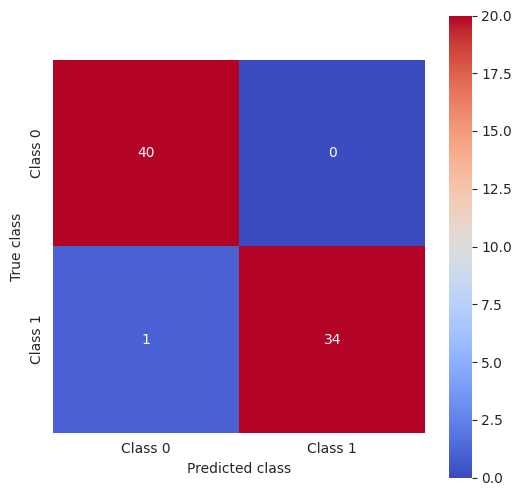

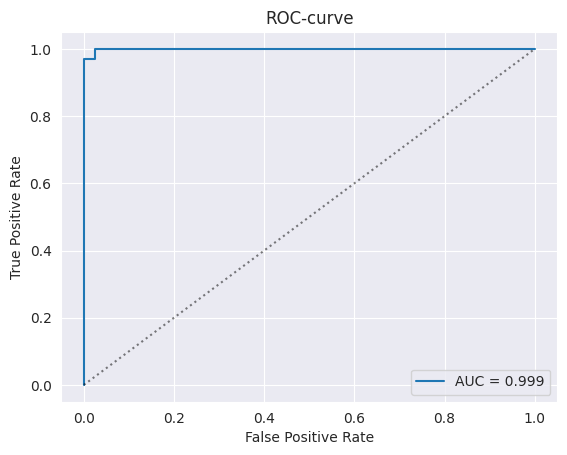

ROC–AUC = 0.999


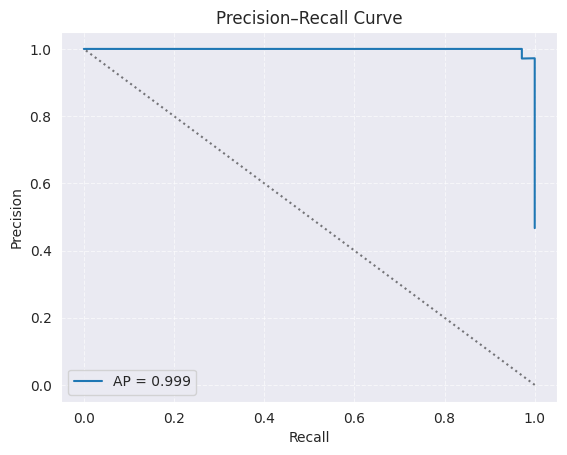

Average (AUC PR) = 0.999


In [87]:
print("Evaluation metrics for train set:")
get_classifier_score(X_train, y_train, grid_mlp)

print("Evaluation metrics for test set:")
get_classifier_score(X_test, y_test, grid_mlp)
plot_roc_auc(X_test, y_test,grid_mlp)
plot_pr_curve(X_test, y_test,grid_mlp)

In [88]:
# Overfitting
train_acc = accuracy_score(y_train, grid_mlp.predict(X_train))
test_acc = accuracy_score(y_test, grid_mlp.predict(X_test))
print(f"{(train_acc - test_acc):.4f}")

0.0133


Після підбору гіперпараметрів точність моделі підвищилася до **99%**. Таким чином, оптимізація архітектури дозволила \
покращити узагальнювальну здатність модель та зменшити помилки класифікації.